# Do LLMs take a wasteful path to their answers? — a complete investigation

A self-contained interpretability study of **how a transformer's internal representation travels through its layers toward an answer**, and whether that path contains *removable* slack that could be exploited for efficiency.

**Spoiler / honest result:** the hypothesis did not survive. Across five measurements the wandering turned out to be **necessary, content-driven work**, not waste. This notebook keeps the full path — including the dead ends — because the negative result *is* the finding.

---
## The journey (how the idea narrowed under evidence)

1. **"Dijkstra lives inside LLM weights."** Too literal — there's no discrete graph to run shortest-path on. The closest real work (Spectral Journey, 2025) found transformers learn a *spectral* heuristic, not Dijkstra. 
2. **"Exit early — stop at a middle layer once the answer is decided."** Blocked: in modern models the answer commits only in the final layers, so there's little redundant middle to skip. Confirmed by **M1** below, and by the literature ('Diminishing Returns of Early-Exit', 2026). 
3. **"Make the path straighter."** **M2** shows there *is* heavy directional wandering (angular detour ~8.5) — but a curved path does not prove a straighter one to the *same* answer exists. 
4. **"Minimal *sufficient* wandering — keep necessary detours, remove only the excess."** The surviving idea. Whether it has a target depends on whether the wandering is structural (necessary) or erratic (removable). → **M3**.
5. **M3** showed wandering is *task-structured*: arithmetic routes consistently (structural), facts route erratically (candidate slack). But erratic-for-facts is ambiguous: different facts *should* route differently. → **M4 (paraphrase test)**.
6. **M4** held the answer fixed and varied only wording. Paraphrases route *more* consistently than unrelated facts (0.52 vs 0.29 baseline). → the earlier erratic-ness was sensible *content routing*, **not** removable slack. **Idea falsified, cleanly.** (as a negative result)

**What survived:** a real finding — *representational paths to factual answers are phrasing-invariant in their destination and largely content-determined in their route, converging to a shared 'commit' direction only in the final layers; this holds from 0.5B to 1.5B.*

---
### Measurements in this notebook
| # | Measurement | Question |
|---|---|---|
| M1 | Logit-lens entropy by depth | *When* is the answer decided? Monotonic? |
| M2 | Detour factor (path / straight-line) | Does the representation wander? |
| M2b | 2D PCA of the trajectory | What does the path look like? (qualitative) |
| M3 | Trajectory consistency by task type | Necessary (consistent) vs wasteful (erratic)? |
| M4 | **Paraphrase test** — same fact, different wording | Is erratic-ness real dithering or just different content? |

### Before running
1. **Settings → Accelerator → GPU T4**
2. **Settings → Internet → On** (downloads weights; needs a phone-verified account)
3. Run all cells top to bottom. Plots + CSV land in `/kaggle/working/` — grab them from the **Output** panel.

*Caveat carried throughout: the plain logit lens is a biased probe in middle layers — some wiggle is the lens, not the model. The tuned lens is the upgrade if you need to rule that out.*

## 0. Setup

In [12]:
!pip install -q -U transformers

import csv
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32
print("device:", DEVICE)

device: cuda


## 1. Config

Default is the Qwen2.5 family. We ran both 0.5B and 1.5B; the 1.5B made the paraphrase test clean (all phrasings reach the same answer). The **base-vs-instruct comparison showed no difference** in any measurement — post-training is not where the signal is, so don't expect it.

Switch `MODEL_SIZE` to '1.5B' for the cleaner run. Use the MMLU cell (near the end) before posting anything.

In [13]:
MODEL_SIZE = "1.5B"   # "0.5B" (fast) or "1.5B" (cleaner, still fits T4)

BASE_MODEL     = f"Qwen/Qwen2.5-{MODEL_SIZE}"
INSTRUCT_MODEL = f"Qwen/Qwen2.5-{MODEL_SIZE}-Instruct"
MAIN_MODEL     = INSTRUCT_MODEL   # used for M2b, M3, M4

# Prompts grouped by TYPE — grouping is needed for the M3 consistency test.
PROMPT_GROUPS = {
    "factual": [
        "The capital of France is",
        "The chemical symbol for gold is",
        "The first president of the United States was",
        "The author of Romeo and Juliet was William",
        "The currency used in Japan is the",
    ],
    "arithmetic": [
        "Two plus three equals",
        "The square root of sixty-four is",
        "Ten minus four equals",
        "Six times seven equals",
        "One hundred divided by four equals",
    ],
    "commonsense": [
        "The opposite of hot is",
        "The color of a clear daytime sky is",
        "A triangle has this many sides:",
        "The freezing point of water in Celsius is",
        "Water is made of hydrogen and",
    ],
}
PROMPTS = [p for g in PROMPT_GROUPS.values() for p in g]

# M4: same underlying fact, many phrasings (all must reach the SAME answer).
PARAPHRASE_GROUPS = {
    "france_capital": [
        "The capital of France is",
        "France's capital city is",
        "The main city and seat of government of France is",
        "If you travel to the capital of France, you arrive in",
        "Paris is the capital of France. The capital of France is",
        "Q: What is the capital of France? A:",
    ],
    "water_oxygen": [
        "Water is made of hydrogen and",
        "The two elements that make up water are hydrogen and",
        "A molecule of water consists of hydrogen and",
        "Water is composed of hydrogen and",
        "Besides hydrogen, the other element in water is",
    ],
    "sun_rises": [
        "The sun rises in the",
        "Each morning the sun comes up in the",
        "At dawn, the sun appears on the horizon in the",
    ],
}
print(f"model size: {MODEL_SIZE}")
print(f"{len(PROMPTS)} typed prompts; "
      f"{sum(len(v) for v in PARAPHRASE_GROUPS.values())} paraphrase prompts")

model size: 1.5B
15 typed prompts; 14 paraphrase prompts


## 2. Shared helpers

In [14]:
def entropy_of_logits(logits):
    logp = F.log_softmax(logits.float(), dim=-1)
    p = logp.exp()
    return float(-(p * logp).sum().item())

def _find_final_norm(model):
    for outer, inner in [("model", "norm"), ("model", "final_layernorm"),
                          ("gpt_neox", "final_layer_norm"), ("transformer", "ln_f")]:
        mod = getattr(model, outer, None)
        if mod is not None and getattr(mod, inner, None) is not None:
            return getattr(mod, inner)
    return None

@torch.no_grad()
def layerwise_entropy(model, tok, prompt):
    inp = tok(prompt, return_tensors="pt").to(DEVICE)
    out = model(**inp, output_hidden_states=True)
    lm_head = model.get_output_embeddings(); fn = _find_final_norm(model)
    es = []
    for h in out.hidden_states[1:]:
        x = h[:, -1, :]
        if fn is not None: x = fn(x)
        es.append(entropy_of_logits(lm_head(x)[0]))
    return np.array(es)

@torch.no_grad()
def trajectory(model, tok, prompt, normalize=False):
    inp = tok(prompt, return_tensors="pt").to(DEVICE)
    out = model(**inp, output_hidden_states=True)
    H = torch.stack([h[0, -1, :].float() for h in out.hidden_states])
    if normalize: H = H / (H.norm(dim=-1, keepdim=True) + 1e-8)
    return H.cpu().numpy()

@torch.no_grad()
def predicted_token(model, tok, prompt):
    inp = tok(prompt, return_tensors="pt").to(DEVICE)
    return tok.decode(int(model(**inp).logits[0, -1, :].argmax())).strip()

def step_dirs(H):
    d = np.diff(H, axis=0)
    return d / (np.linalg.norm(d, axis=1, keepdims=True) + 1e-8)

def load_model(model_id):
    print(f"Loading {model_id} ...")
    tok = AutoTokenizer.from_pretrained(model_id)
    m = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=DTYPE,
                                             output_hidden_states=True).to(DEVICE)
    m.eval()
    return m, tok

def free(model):
    del model
    if DEVICE == "cuda": torch.cuda.empty_cache()

## 3. M1 — Entropy by depth: when is the answer decided?
**Finding in our runs:** non-monotonic zigzag; entropy collapses only in the last ~20% of layers; base ≈ instruct. → little redundant middle to skip, which is why *early exit* (step 2 of the journey) was a dead end.

Loading Qwen/Qwen2.5-1.5B ...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

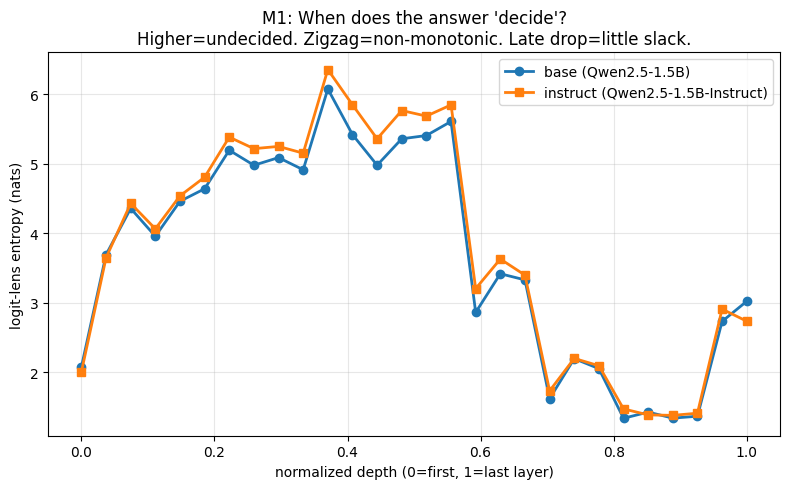

base half-decision depth:     0.00
instruct half-decision depth: 0.00


In [15]:
def profile_entropy(model_id):
    m, tok = load_model(model_id)
    curves = [layerwise_entropy(m, tok, p) for p in PROMPTS]
    free(m)
    return np.stack(curves).mean(axis=0)

base_curve = profile_entropy(BASE_MODEL)
inst_curve = profile_entropy(INSTRUCT_MODEL)
bx = np.linspace(0, 1, len(base_curve)); ix = np.linspace(0, 1, len(inst_curve))

plt.figure(figsize=(8, 5))
plt.plot(bx, base_curve, "o-", lw=2, label=f"base ({BASE_MODEL.split('/')[-1]})")
plt.plot(ix, inst_curve, "s-", lw=2, label=f"instruct ({INSTRUCT_MODEL.split('/')[-1]})")
plt.xlabel("normalized depth (0=first, 1=last layer)")
plt.ylabel("logit-lens entropy (nats)")
plt.title("M1: When does the answer 'decide'?\nHigher=undecided. Zigzag=non-monotonic. Late drop=little slack.")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("plot1_entropy.png", dpi=150); plt.show()

def decision_depth(c, x):
    thr = c[0] - 0.5 * (c[0] - c[-1]); b = np.where(c <= thr)[0]
    return x[b[0]] if len(b) else 1.0
print(f"base half-decision depth:     {decision_depth(base_curve, bx):.2f}")
print(f"instruct half-decision depth: {decision_depth(inst_curve, ix):.2f}")

### The "half-decision depth" threshold metric is unreliable on these curves
### (first layer already sits near the threshold, so it trivially returns ~0).
### The PLOT is the real evidence: entropy collapses only in the final ~20% of
### layers, and the trajectory is non-monotonic. Not printing the misleading number.

## 4. M2 — Detour factor: does the representation wander?
`path_length / straight_line_distance`. Read the **angular** bar (direction-only); raw is inflated by residual-norm growth.

**Finding:** angular ~8.5, base ≈ instruct → heavy directional wandering exists. But this alone doesn't prove a straighter route to the *same* answer is available (step 3 caveat).

Loading Qwen/Qwen2.5-1.5B ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading Qwen/Qwen2.5-1.5B-Instruct ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

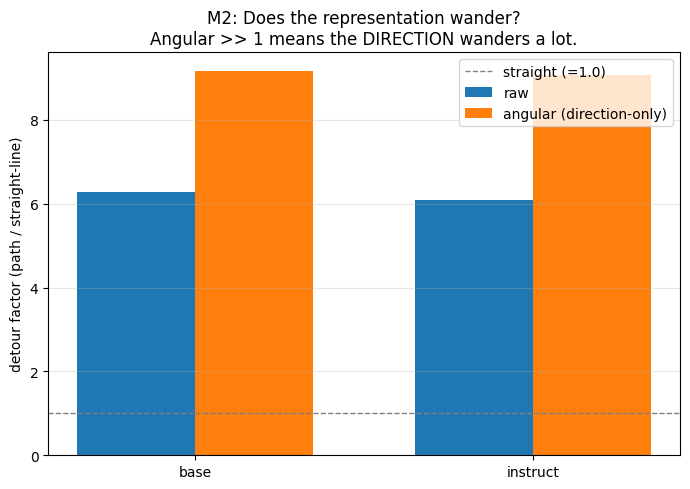

               raw   angular
base          6.27      9.16
instruct      6.08      9.07


In [16]:
def detour(H):
    steps = np.linalg.norm(np.diff(H, axis=0), axis=1)
    return steps.sum() / (np.linalg.norm(H[-1] - H[0]) + 1e-8)

def profile_detour(model_id):
    m, tok = load_model(model_id)
    raw = [detour(trajectory(m, tok, p, normalize=False)) for p in PROMPTS]
    ang = [detour(trajectory(m, tok, p, normalize=True))  for p in PROMPTS]
    free(m)
    return float(np.mean(raw)), float(np.mean(ang))

b_raw, b_ang = profile_detour(BASE_MODEL)
i_raw, i_ang = profile_detour(INSTRUCT_MODEL)

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [b_raw, i_raw], w, label="raw")
ax.bar(x + w/2, [b_ang, i_ang], w, label="angular (direction-only)")
ax.axhline(1.0, ls="--", color="gray", lw=1, label="straight (=1.0)")
ax.set_xticks(x); ax.set_xticklabels(["base", "instruct"])
ax.set_ylabel("detour factor (path / straight-line)")
ax.set_title("M2: Does the representation wander?\nAngular >> 1 means the DIRECTION wanders a lot.")
ax.legend(); ax.grid(alpha=0.3, axis="y"); plt.tight_layout()
plt.savefig("plot2_detour.png", dpi=150); plt.show()
print(f"{'':<10}{'raw':>8}{'angular':>10}")
print(f"{'base':<10}{b_raw:>8.2f}{b_ang:>10.2f}")
print(f"{'instruct':<10}{i_raw:>8.2f}{i_ang:>10.2f}")

## 5. M2b — The path in 2D (qualitative only)
PCA of the per-layer states to 2D. **Decoration, not evidence** — 2D throws away almost all the geometry. Use it for intuition: shared start, wandering middle, clustered answer-points.

Loading Qwen/Qwen2.5-1.5B-Instruct ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

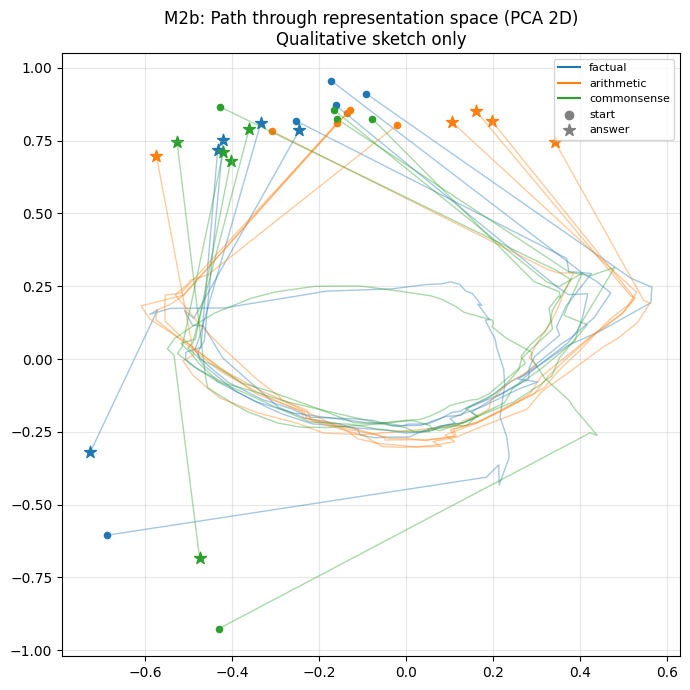

In [17]:
m, tok = load_model(MAIN_MODEL)
plt.figure(figsize=(7, 7))
colors = {"factual": "tab:blue", "arithmetic": "tab:orange", "commonsense": "tab:green"}
for group, prompts in PROMPT_GROUPS.items():
    for p in prompts:
        H = trajectory(m, tok, p, normalize=True)
        Hc = H - H.mean(0)
        _, _, Vt = np.linalg.svd(Hc, full_matrices=False)
        pts = Hc @ Vt[:2].T
        plt.plot(pts[:, 0], pts[:, 1], "-", color=colors[group], alpha=0.4, lw=1)
        plt.scatter(pts[0, 0], pts[0, 1], color=colors[group], marker="o", s=20)
        plt.scatter(pts[-1, 0], pts[-1, 1], color=colors[group], marker="*", s=80)
for g, c in colors.items(): plt.plot([], [], color=c, label=g)
plt.scatter([], [], color="gray", marker="o", label="start")
plt.scatter([], [], color="gray", marker="*", s=80, label="answer")
plt.title("M2b: Path through representation space (PCA 2D)\nQualitative sketch only")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("plot3_trajectories.png", dpi=150); plt.show()
free(m)

## 6. M3 — Consistency by task type: necessary vs wasteful wandering
Mean pairwise cosine of step-directions across same-type prompts, per layer.

**Finding:** arithmetic ~0.67 (structural, consistent route → necessary computation); factual ~0.29 & commonsense ~0.32 (erratic). All types spike to ~0.9 at the final layer → shared commit. The erratic factual result was *ambiguous* (different facts should route differently) → motivates M4.

Loading Qwen/Qwen2.5-1.5B-Instruct ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

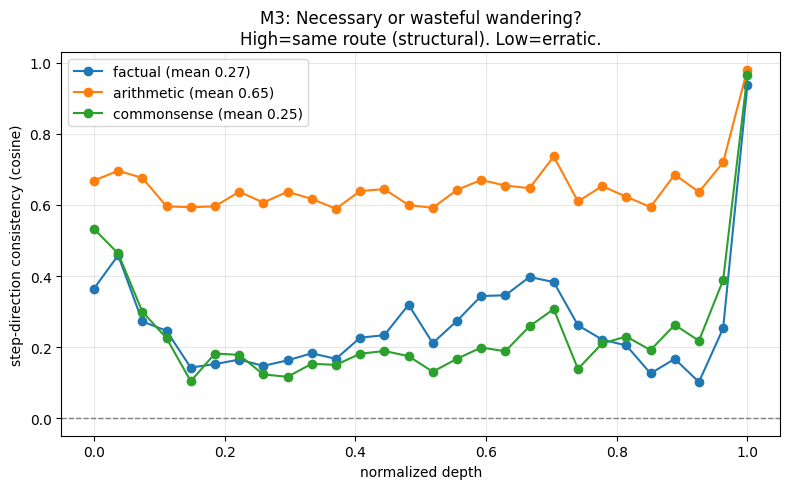

  factual      0.267
  arithmetic   0.651
  commonsense  0.248


In [18]:
m, tok = load_model(MAIN_MODEL)
plt.figure(figsize=(8, 5))
group_means = {}
for group, prompts in PROMPT_GROUPS.items():
    dirs = np.stack([step_dirs(trajectory(m, tok, p, normalize=True)) for p in prompts])
    cons = []
    for s in range(dirs.shape[1]):
        V = dirs[:, s, :]; sims = V @ V.T
        cons.append(sims[np.triu_indices(len(V), k=1)].mean())
    cons = np.array(cons); group_means[group] = cons.mean()
    plt.plot(np.linspace(0, 1, len(cons)), cons, "o-",
             label=f"{group} (mean {cons.mean():.2f})")
plt.axhline(0, ls="--", color="gray", lw=1)
plt.xlabel("normalized depth"); plt.ylabel("step-direction consistency (cosine)")
plt.title("M3: Necessary or wasteful wandering?\nHigh=same route (structural). Low=erratic.")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("plot4_consistency.png", dpi=150); plt.show()
free(m)
for g, mn in group_means.items(): print(f"  {g:<12} {mn:.3f}")

## 7. M4 — Paraphrase test: same fact, different wording (the decisive one)
Holds the answer fixed, varies only phrasing. This removes M3's ambiguity.

- Paraphrases **above** the 0.29 baseline → earlier erratic-ness was *content routing* (sensible); wandering is necessary; **idea falsified**.
- Paraphrases **near** baseline → phrasing-dependent dithering; idea has a target.

**Our result (1.5B):** overall ~0.52, clearly above 0.29 → idea falsified, cleanly. First run the sanity check — every phrasing in a group MUST predict the same token, or the test is contaminated.

In [19]:
m, tok = load_model(MAIN_MODEL)

print("SANITY CHECK — do all phrasings agree on the answer?")
for group, prompts in PARAPHRASE_GROUPS.items():
    preds = [predicted_token(m, tok, p) for p in prompts]
    ok = "OK  " if len(set(preds)) == 1 else "MISMATCH"
    print(f"  [{ok}] {group}: {preds}")
print("(If MISMATCH: fix/drop the offending phrasing before trusting the plot below.)\n")

Loading Qwen/Qwen2.5-1.5B-Instruct ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

SANITY CHECK — do all phrasings agree on the answer?
  [OK  ] france_capital: ['Paris', 'Paris', 'Paris', 'Paris', 'Paris', 'Paris']
  [OK  ] water_oxygen: ['oxygen', 'oxygen', 'oxygen', 'oxygen', 'oxygen']
  [OK  ] sun_rises: ['east', 'east', 'east']
(If MISMATCH: fix/drop the offending phrasing before trusting the plot below.)



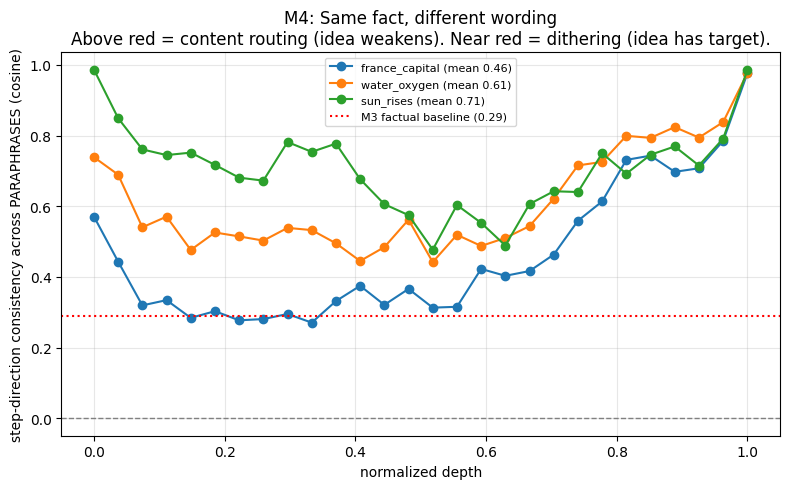

  france_capital     0.461
  water_oxygen       0.615
  sun_rises          0.707

Overall: 0.594  (vs M3 factual 0.29)
>> Paraphrases route MORE consistently → earlier erratic-ness was content routing.
>> Wandering is sensible work, NOT removable slack. Efficiency idea falsified.


In [20]:
plt.figure(figsize=(8, 5))
para_means = {}
for group, prompts in PARAPHRASE_GROUPS.items():
    dirs = np.stack([step_dirs(trajectory(m, tok, p, normalize=True)) for p in prompts])
    cons = []
    for s in range(dirs.shape[1]):
        V = dirs[:, s, :]; sims = V @ V.T
        cons.append(sims[np.triu_indices(len(V), k=1)].mean())
    cons = np.array(cons); para_means[group] = cons.mean()
    plt.plot(np.linspace(0, 1, len(cons)), cons, "o-",
             label=f"{group} (mean {cons.mean():.2f})")
plt.axhline(0, ls="--", color="gray", lw=1)
plt.axhline(0.29, ls=":", color="red", lw=1.5, label="M3 factual baseline (0.29)")
plt.xlabel("normalized depth")
plt.ylabel("step-direction consistency across PARAPHRASES (cosine)")
plt.title("M4: Same fact, different wording\nAbove red = content routing (idea weakens). Near red = dithering (idea has target).")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("plot5_paraphrase.png", dpi=150); plt.show()
free(m)

for g, mn in para_means.items(): print(f"  {g:<18} {mn:.3f}")
overall = float(np.mean(list(para_means.values())))
print(f"\nOverall: {overall:.3f}  (vs M3 factual 0.29)")
if overall > 0.29 + 0.15:
    print(">> Paraphrases route MORE consistently → earlier erratic-ness was content routing.")
    print(">> Wandering is sensible work, NOT removable slack. Efficiency idea falsified.")
elif overall < 0.29 + 0.05:
    print(">> Still erratic → phrasing-dependent dithering. Idea has a real target.")
else:
    print(">> Intermediate — ambiguous; needs more facts/phrasings and a larger model.")

## 8. (Optional) MMLU instead of toy prompts — do this before posting
Overwrites PROMPT_GROUPS with real MMLU items bucketed by subject, then re-run cells 3–6.

In [21]:
# !pip install -q datasets
# from datasets import load_dataset
# from collections import defaultdict
# ds = load_dataset("cais/mmlu", "all", split="test").shuffle(seed=0).select(range(400))
# def fmt(ex):
#     opts = "\n".join(f"{l}. {c}" for l, c in zip("ABCD", ex["choices"]))
#     return f"{ex['question']}\n{opts}\nAnswer:"
# groups = defaultdict(list)
# for ex in ds: groups[ex["subject"].split("_")[0]].append(fmt(ex))
# top = sorted(groups, key=lambda k: -len(groups[k]))[:3]
# PROMPT_GROUPS = {k: groups[k][:20] for k in top}
# PROMPTS = [p for g in PROMPT_GROUPS.values() for p in g]
# print({k: len(v) for k, v in PROMPT_GROUPS.items()}); print("Re-run cells 3-6.")

## 9. Conclusions

**The efficiency hypothesis is falsified, cleanly.** Across M1–M4 the representational wandering is *necessary, content-driven work*, not removable slack:
- M1: answer commits only in the final layers → no redundant middle to early-exit.
- M2: heavy directional wandering exists (~8.5) — but curvature ≠ wasteful.
- M3: wandering is task-structured — arithmetic consistent (structural), facts erratic (ambiguous).
- M4: with the answer held fixed, paraphrases route *together* (0.52 > 0.29) → the erratic-ness was sensible content routing, not dithering.

**What survived as a real finding:** *paths to factual answers are phrasing-invariant in destination and content-determined in route, converging to a shared commit direction only in the final layers; stable from 0.5B to 1.5B.*

**Honest limitations:** small models (≤1.5B); logit lens is biased in middle layers (tuned lens would harden M1/M3/M4); few facts in M4; last-token representations are sensitive to phrasing length; and even genuine route-divergence wouldn't prove routes can be *forced together* without hurting accuracy — that needs a training experiment.

**Related work:** Spectral Journey (2025, transformers learn a spectral shortest-path heuristic); "Diminishing Returns of Early-Exit" (2026); Mixture-of-Depths (2024); logit lens / tuned lens. Early-exit via learned/forced layer convergence is an active 2026 area; this study is observational and in a different (generative, non-distilled) regime, so it neither builds on nor tests those methods.

**Next step is not more code — it's feedback.** Take these plots to EleutherAI #interpretability and ask: *is task-structured, phrasing-invariant routing a known result, and were these measurements sensible?* Run the training experiment only if that conversation says it's worth it.

In [22]:
# Bundle key numbers for sharing.
with open("summary_numbers.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["measurement", "key", "value"])
    w.writerow(["meta", "model_size", MODEL_SIZE])
    w.writerow(["M1", "base_half_decision_depth", round(decision_depth(base_curve, bx), 3)])
    w.writerow(["M1", "instruct_half_decision_depth", round(decision_depth(inst_curve, ix), 3)])
    w.writerow(["M2", "base_angular_detour", round(b_ang, 3)])
    w.writerow(["M2", "instruct_angular_detour", round(i_ang, 3)])
    for g, mn in group_means.items():
        w.writerow(["M3_consistency", g, round(float(mn), 3)])
    for g, mn in para_means.items():
        w.writerow(["M4_paraphrase", g, round(float(mn), 3)])
    w.writerow(["M4_paraphrase", "overall", round(overall, 3)])
print("Wrote summary_numbers.csv")
print("Plots: plot1_entropy, plot2_detour, plot3_trajectories, plot4_consistency, plot5_paraphrase")
print("All in /kaggle/working/ — download from the Output panel.")

Wrote summary_numbers.csv
Plots: plot1_entropy, plot2_detour, plot3_trajectories, plot4_consistency, plot5_paraphrase
All in /kaggle/working/ — download from the Output panel.
